In [19]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer,KBinsDiscretizer,OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np # linear algebra
import pandas as pd

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    precision_recall_curve,
    classification_report
)
from sklearn.compose import ColumnTransformer

In [3]:
df= pd.read_csv("datos/train.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

In [5]:
num = df.select_dtypes(include='number').columns.tolist()
cat = df.select_dtypes(exclude='number').columns.tolist()
print("==============Categoricas==========================")
print(cat)
print("===============Numericas=========================")
print(num)

==============Categoricas==========================
['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV']
===============Numericas=========================
['id', 'Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']


In [6]:
cat=['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level']
num=['Age', 'Annual_Income_USD', 'Daily_Commute_km',
       'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
       'Charging_Stations_Near_Work', 'Environmental_Concern_Level']

In [7]:
X = df.drop(columns=['id', 'Will_Buy_EV'])
for c in cat:
    X[c] = X[c].astype('category')
y = df['Will_Buy_EV'].map({'No': 0, 'Yes': 1})

X_train, X_val, y_train, y_val = train_test_split(
    X, y, train_size=0.8, random_state=42, stratify=y)

In [12]:
preprocessor_nb = ColumnTransformer(transformers=[
    ("num", KBinsDiscretizer(n_bins=10, encode="ordinal", strategy="quantile"), num),
    ("cat", OrdinalEncoder(), cat),
])

In [13]:
preprocessor_nb = ColumnTransformer(transformers=[
    ("num", KBinsDiscretizer(n_bins=10, encode="ordinal", strategy="quantile"), num),
    ("cat", OrdinalEncoder(), cat),
])

model_nb = Pipeline(steps=[
    ("prep", preprocessor_nb),
    ("nb", CategoricalNB(alpha=1.0)),
])

model_nb.fit(X_train, y_train)

proba_nb = model_nb.predict_proba(X_val)[:, 1]
print("AUC Naive Bayes:", roc_auc_score(y_val, proba_nb))

C:\Users\USUARIO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\USUARIO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\USUARIO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\USUARIO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. C

AUC Naive Bayes: 0.9290030167404757


In [14]:
print(X_train[num].nunique())

Age                               45
Annual_Income_USD              12406
Daily_Commute_km                 794
Number_of_Cars_Owned               4
Charging_Stations_Near_Home       15
Charging_Stations_Near_Work       20
Environmental_Concern_Level        5
dtype: int64


In [15]:
LIMITE = 20   # si tiene 20 valores únicos o menos, se trata como categórica

num_discretas  = [c for c in num if X_train[c].nunique() <= LIMITE]
num_continuas  = [c for c in num if X_train[c].nunique() > LIMITE]

print("Discretas:", num_discretas)
print("Continuas:", num_continuas)

preprocessor_nb = ColumnTransformer(transformers=[
    ("cont", KBinsDiscretizer(n_bins=10, encode="ordinal", strategy="quantile"), num_continuas),
    ("disc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), num_discretas),
    ("cat",  OrdinalEncoder(), cat),
])

model_nb = Pipeline(steps=[
    ("prep", preprocessor_nb),
    ("nb", CategoricalNB(alpha=1.0, min_categories=None)),
])

model_nb.fit(X_train, y_train)
proba_nb = model_nb.predict_proba(X_val)[:, 1]
print("AUC Naive Bayes:", roc_auc_score(y_val, proba_nb))

Discretas: ['Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']
Continuas: ['Age', 'Annual_Income_USD', 'Daily_Commute_km']


C:\Users\USUARIO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


AUC Naive Bayes: 0.9364821622736467


In [16]:
y_pred_nb = model_nb.predict(X_val)
proba_nb = model_nb.predict_proba(X_val)[:, 1]

auc_nb = roc_auc_score(y_val, proba_nb)

print(f"AUC Naive Bayes: {auc_nb:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_nb))

AUC Naive Bayes: 0.9365

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.94    110377
           1       0.72      0.63      0.67     23356

    accuracy                           0.89    133733
   macro avg       0.82      0.79      0.80    133733
weighted avg       0.89      0.89      0.89    133733



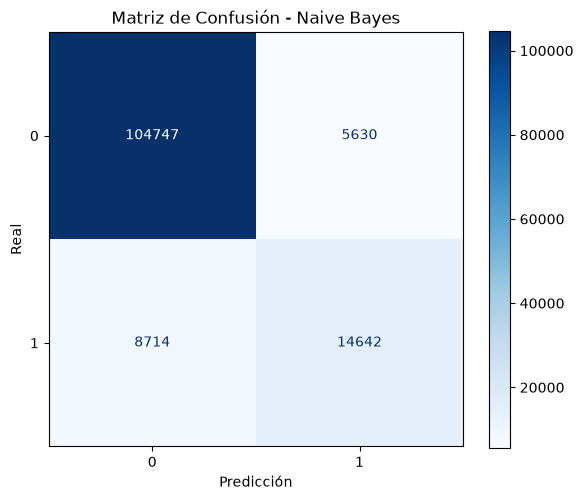

In [20]:
cm = confusion_matrix(y_val, y_pred_nb)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_nb.classes_
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

ax.set_title("Matriz de Confusión - Naive Bayes")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

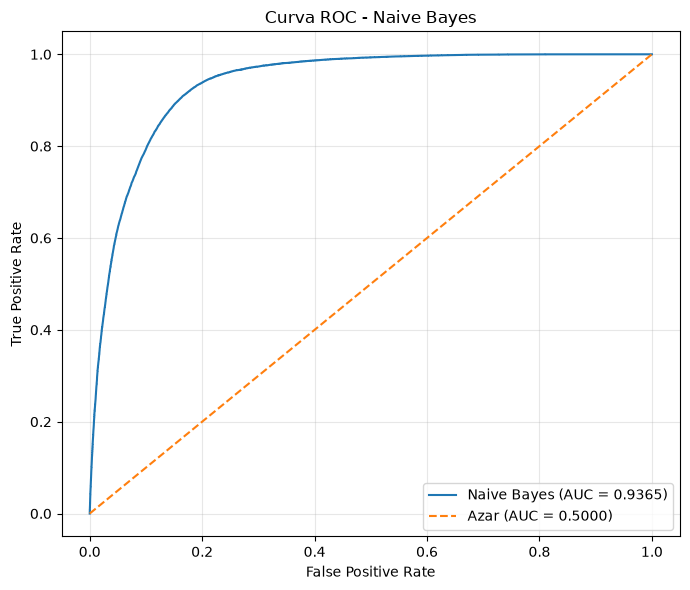

In [21]:
fpr, tpr, thresholds = roc_curve(y_val, proba_nb)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Naive Bayes (AUC = {auc_nb:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Azar (AUC = 0.5000)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Naive Bayes")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
import joblib
import sklearn

artefacto_nb = {
    "model": model_nb,
    "features": X_train.columns.tolist(),
    "auc_validacion": float(roc_auc_score(y_val, proba_nb)),
    "sklearn_version": sklearn.__version__,
}
joblib.dump(artefacto_nb, "modelo/naive_bayes.joblib", compress=3)

print("Guardado. AUC validación:", artefacto_nb["auc_validacion"])



Guardado. AUC validación: 0.9364821622736467


In [33]:
artefacto_nb = joblib.load("modelo/naive_bayes.joblib")
model_nb = artefacto_nb["model"]
df_test = pd.read_csv("datos/test.csv")
X_test = df_test[artefacto_nb["features"]]

proba_test_nb = model_nb.predict_proba(X_test)[:, 1]

pd.DataFrame({
    "id": df_test["id"],
    "Will_Buy_EV": proba_test_nb,
}).to_csv("predicciones/predicciones_naive_bayes.csv", index=False)

print(proba_test_nb.min(), proba_test_nb.max())

1.2174022298419865e-07 0.9283374078937423
